<a href="https://colab.research.google.com/github/adrianacalderon/CaribbeanTraining/blob/main/5_HydroSOS_Status.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

# **Introduction**

**HydroSOS** is a World Meteorological Organization initiative that aims to strengthen the capacity of National Hydrological and Meteorological Services to manage water resources through the development of hydrological status and outlook products. HydroSOS seeks to enable an assessment of the current state of water resources relative to "expected" or "normal" conditions, as well as hydrological outlooks on how this state may change over the following weeks and months. Within the context of the HydroSOS initiative, a portal showcasing status and future outlooks has been created, which can be accessed at: https://wmohydrosos.ceh.ac.uk/portal.

In this tutorial, we will apply the HydroSOS methodology to determine the **monthly hydrological status** at a point (e.g., a hydrometric station) where observed streamflow data is available. The methodology consists of transforming the observed streamflow into a percentile relative to the historical record for the corresponding time of year — for example, the current month — and classifying the resulting percentile according to a predetermined flow category.

**Note: Make sure you are using the most up-to-date version of the HydroSOS notebook, available on the HydroSOS GitHub repository.**

---

# **Clone the HydroSOS repository**

Clone the WMO HydroSOS repository hosted on Gitub

We are cloning the notebook, mainly to access the sample data in order to run the status calculation.

*   Note: To use the `git clone` command on another notebook/Python script execution platform (e.g., ***Jupyter***, ***Visual Studio Code***), you need to make sure that `Git` is installed on your computer. Otherwise, Git can be downloaded at (https://git-scm.com/downloads)

In [ ]:
!git clone https://github.com/wmo-im/HydroSOS/

Cloning into 'HydroSOS'...
remote: Enumerating objects: 2177, done.
remote: Counting objects: 100% (216/216), done.
remote: Compressing objects: 100% (131/131), done.
remote: Total 2177 (delta 143), reused 129 (delta 79), pack-reused 1961 (from 1)
Receiving objects: 100% (2177/2177), 2.33 MiB | 15.18 MiB/s, done.
Resolving deltas: 100% (1805/1805), done.


---

# **Import Python libraries**

Import the required libraries to run this tutorial:

In [ ]:
import numpy as np
import pandas as pd
import os

from datetime import datetime
from matplotlib import pyplot as plt
from matplotlib import patches as mpatches
from pathlib import Path

---

# **Create a new folder**

Create an output folder in the root directory to export the results:

In [ ]:
# Define folder path (e.g., in the current working directory)
folder_output = 'output'

# Create the folder if it doesn't exist
os.makedirs(folder_output, exist_ok=True)

---

# **1. Define parameters

Define the parameters to generate the hydrological status:

*   `File path`: Path where the .csv file with daily streamflow data is located
*   `min_valid_frac`: Minimum fraction of valid daily data in a month required to convert it to a monthly average
*   `clim_startYear`: Start year of the reference period for calculating the percentiles
*   `clim_endYear`: End year of the reference period for calculating the percentiles
*   `perc_categories`: List of percentiles indicating the thresholds for the hydrological categories
*   `name_categories`: List of names defining the categories
*   `color_codes`: List of colors for the categories


In [ ]:
# Copy the path where input files are located
file_path = './HydroSOS/example_data/status/input/12001.csv' # Path to your CSV file

min_valid_frac = 0.5              # Minimum fraction of valid daily data per month (default = 50%)
clim_startYear = 1991             # Start year to compute statistics (mean, percentiles)
clim_endYear = 2020               # End year to compute statistics

# HydroSOS percentiles below of which (<=) flows are categorized (do not include 0.0)
perc_categories = [0.1, 0.25, 0.75, 0.9, 1.0]
name_categories = ['Low Flow', 'Below Normal', 'Normal', 'Above Normal', 'High Flow']

# Color codes (HEX) according to HydroSOS standards
color_codes = ['#CD233f','#FFA885','#E7E2BC','#8ECEEE','#2C7DCD']

The percentiles indicated could be modified to fit the user's classification of interest, but here we will keep these percentiles to mirror HydroSOS standards.

---

# **2. Read the data**

2.1. Read the .csv file with the daily streamflow data and convert it to monthly. The .csv file must have 2 columns (one with the dates, and another with the streamflow values), in addition to:

*   The title of the date column defined as '*Date*' (without quotes)
*   The dates in **YYYY-MM-DD** format

In [ ]:
# Read and preprocess data
df = pd.read_csv(file_path)
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')
df.set_index('date', inplace=True)

# Ensure data comes in sorted position
df.sort_index(inplace=True)
df.index.name = 'date'
# Ensure column name = Streamflow
df.columns = ['Streamflow']

# Convert to monthly data
df_month = df.resample('MS').mean()

2.2. Plot the streamflow graph:

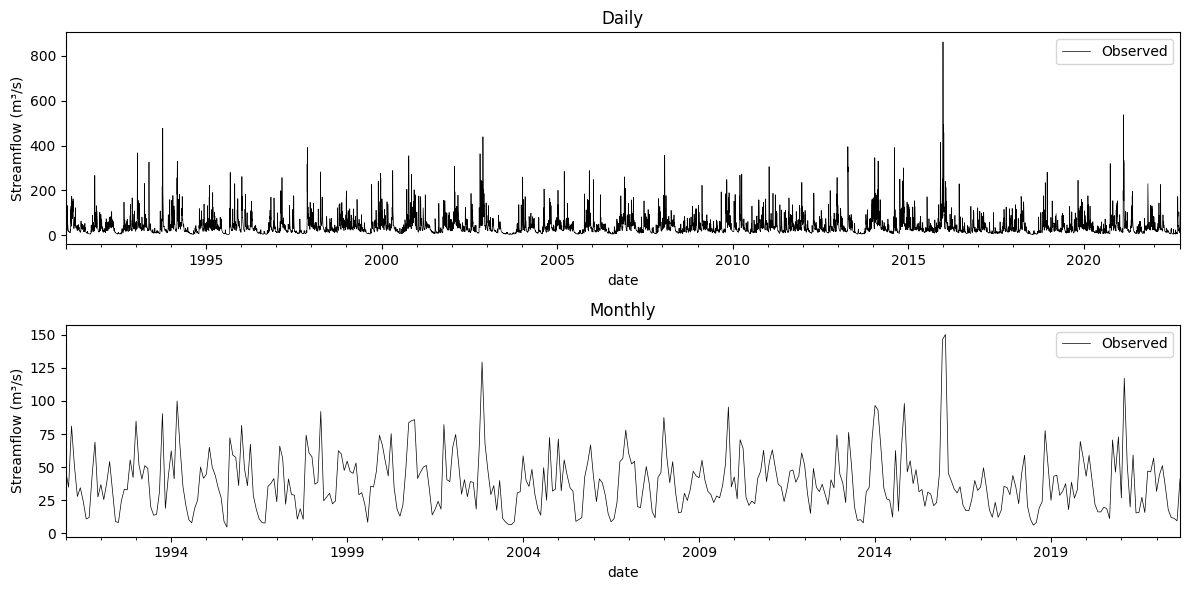

In [ ]:
#@title Plot
# Plot on screen (subplot for daily and monthly data)
from matplotlib import pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes = axes.flatten()

df.plot(ax=axes[0], color='k', linewidth=0.5, title='Daily')
df_month.plot(ax=axes[1], color='k', linewidth=0.5, title='Monthly')

for ax in axes:
  ax.set_ylabel('Streamflow (m³/s)')
  ax.legend(['Observed'])

plt.tight_layout()
plt.show()

---

# **3. Pre-processing of monthly data**

3.1. Apply basic processing of the data. The data must not contain gaps in the dates (for example, jumping from 1991-01-07 to 1991-01-09 without a record for the 08th). We must make sure that the series is continuous and add any missing dates (with invalid data) if necessary:

In [ ]:
# Check if there are date differences between the full range of datetimes and datetimes informed
full_dates = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
diff = full_dates.difference(df.index)

# If there is a difference between the full range of datetimes and the range of dates informed, add the missing dates
if len(diff) > 0:
   for md in diff:
       # Add the missing dates and set nan values
       df.loc[md,'Streamflow'] = np.nan

   # Sort values by date indices
   df.sort_index(inplace=True)

3.2. Remove the months with insufficient daily data according to the minimum defined in the parameters section:

In [ ]:
# Resample daily to monthly step and compute de fraction of dates in each month without missing data
valid_fraction = df.resample('MS').apply(lambda x: x.count() / x.size)

# Replace monthly values to NaN if % of valid < minimum
df_month.mask(valid_fraction < min_valid_frac, np.nan, inplace=True)

3.3. Check some statistics about the existing data (total number of years in the series, % of invalid data):

In [ ]:
# Check whether or not there is enough data?
print(f"* There are {df.index.year.max() - df.index.year.min() + 1} years in this file.")
print(f"* There are {df.isna().sum(axis=0).values} invalid (missing) data points,")
print(f"  which corresponds to {100 * (df.isna().sum(axis=0)/len(df)).values}% of the total data")

* There are 32 years in this file.
* There are [0] invalid (missing) data points,
  which corresponds to [0.]% of the total data


---

# **4. Calculation of streamflow as a percentage of the average**

4.1. First, calculate the average streamflow for each calendar month over our reference period (for example, 1991-2020), so that we have a long-term average monthly streamflow for January, February... December:

NOTE: this isn't actually a critical step in the HydroSOS workflow, you can skip to ranking the data, which can be done on the raw monthly streamflow values, but this gives useful context.

In [ ]:
# Converting date strings to datetime format
dt_start = datetime(clim_startYear, 1, 1)
dt_end = datetime(clim_endYear, 12, 31)

# Get data for the period of interest
monthly_clim = df_month[(df_month.index >= dt_start) &
                        (df_month.index <= dt_end)]

# Compute average for each calendar month
month_nums = monthly_clim.index.month
clim_mean = monthly_clim.groupby(month_nums).mean()

print('Monthly average:')
display(clim_mean)

Monthly average:


,Streamflow
date,
1,56.948183
2,46.277684
3,46.910052
4,45.403624
5,31.380913
6,23.029991
7,19.550872
8,22.277355
9,24.930251


4.2. Check whether there are enough years within the reference period for each calendar month to calculate the percentiles. It would be advisable to have at least 20 years of data (30 is ideal) for an adequate calculation:

**Note:** Please refer to the official "Streamflow Status Product Methodology".


In [ ]:
# Number of years used to compute monthly means
print(f'Reference period: {clim_startYear}-{clim_endYear}')
print(f'Number of years available per month for calculating the monthly average: {monthly_clim.groupby(monthly_clim.index.month).count()}')

Reference period: 1991-2020
Number of years available per month for calculating the monthly average:       Streamflow
date            
1             30
2             30
3             30
4             30
5             30
6             30
7             30
8             30
9             30
10            30
11            30
12            30


4.3. Calculate the monthly average streamflow as a percentage of average, using the established reference period:

In [ ]:
# Copy monthly flows and update it to % of average
df_prct_avg = df_month.copy()

# Compute % of average for each month separately
for i in range(1, 13):
  idx = (df_prct_avg.index.month == i)
  df_prct_avg.loc[idx] = 100 * (df_prct_avg.loc[idx] / clim_mean.loc[i].values)

4.4. Plot streamflow represented as % of the monthly average:

<Axes: title={'center': '% of monthly mean, reference: 1991-2020'}, xlabel='date', ylabel='Streamflow as a % of average'>

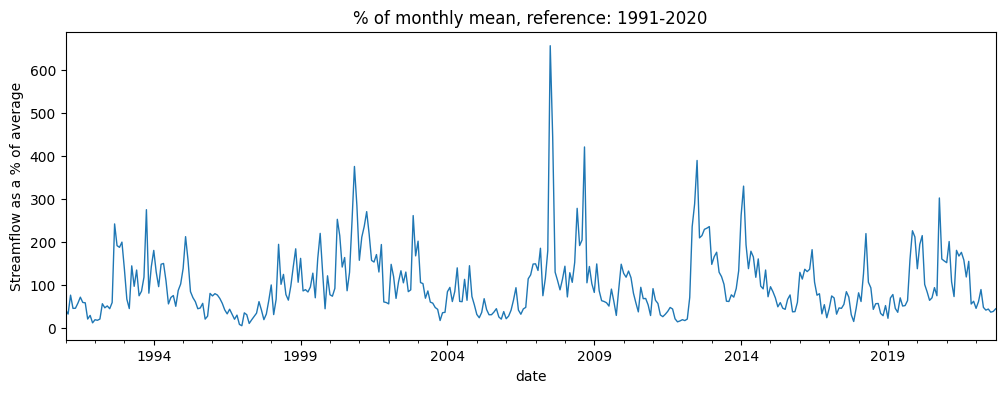

In [ ]:
#@title Plot
# Plot on screen
df_prct_avg.plot(figsize=(12, 4),
                 linewidth=1.0,
                 title=f'% of monthly mean, reference: {clim_startYear}-{clim_endYear}',
                 ylabel='Streamflow as a % of average',
                 legend=False)

---

# **5. Percentile and Rank Calculation**


5.1. In this step we will calculate the rank percentiles, using the flows calculated as % of average from the previous step. First, we identify the ranks occupied by the flows within the historical series. The lowest value will be assigned rank 1, the second lowest value rank 2, and so on. These ranks are relative to the month being analyzed, meaning that January values will be assigned ranks relative to the historical series for January:

In [ ]:
# This block uses a whole series for ranking instead of a set reference period
# Compute number of months with data and ranks
df_n_months = df_prct_avg.groupby(df_prct_avg.index.month).count()
df_ranks = df_prct_avg.groupby(df_prct_avg.index.month).rank(na_option='keep')

# Keep ranks as float format to allow missing (NaN) values
print('Rank position of the percentiles:')
display(df_ranks)

Rank position of the percentiles:


,Streamflow
date,
1991-01-01,7.0
1991-02-01,6.0
1991-03-01,12.0
1991-04-01,5.0
1991-05-01,6.0
...,...
2022-05-01,4.0
2022-06-01,6.0
2022-07-01,5.0


In [ ]:
# this block uses the 30 year window we have defined (1991-2020)
ref_prct_avg = df_prct_avg[(df_prct_avg.index >= dt_start) & (df_prct_avg.index <= dt_end)]

df_n_months = ref_prct_avg.groupby(ref_prct_avg.index.month).count()
df_ranks = ref_prct_avg.groupby(ref_prct_avg.index.month).rank(na_option='keep')
# Keep ranks as float format to allow missing (NaN) values
print('Rank position of the percentiles:')
display(df_ranks)

Rank position of the percentiles:


,Streamflow
date,
1991-01-01,7.0
1991-02-01,6.0
1991-03-01,12.0
1991-04-01,5.0
1991-05-01,5.0
...,...
2020-08-01,21.0
2020-09-01,15.0
2020-10-01,30.0


5.2. Next, we calculate the percentiles corresponding to these ranks. The standard HydroSOS method uses the Weibull distribution:

\begin{align}
   \frac{i}{N+1}
\end{align}

Where:

*   $ i $ is the rank (position) of the flow;
*   $ N $ is the number of months available in the historical record.

In [ ]:
# Creating a dataframe copy to update it afterwards
df_weibull_perc = df_ranks.copy()

# Compute Weibull rank percentiles for each month in the time series
for i in range(1, 13):
  idx = (ref_prct_avg.index.month == i)
  df_weibull_perc.loc[idx] = df_ranks.loc[idx] / (df_n_months.loc[i].values + 1)

print('Rank percentiles:')
display(df_weibull_perc)

Rank percentiles:


,Streamflow
date,
1991-01-01,0.225806
1991-02-01,0.193548
1991-03-01,0.387097
1991-04-01,0.161290
1991-05-01,0.161290
...,...
2020-08-01,0.677419
2020-09-01,0.483871
2020-10-01,0.967742


This cell creates a threshold dictionary, it looks at the rank percentiles and tries to find the flow value that equates to the 10th, 25th, 75th and 90th centiles - interpolating between them if it can't find a close match.

This then creates the look up table for the next step.

In [ ]:
target_ranks = [0.10, 0.25, 0.75, 0.90]
threshold_dict = {}

for i in range(1, 13):
    ranks = df_weibull_perc.loc[ref_prct_avg.index.month == i, 'Streamflow'].values
    percentiles = ref_prct_avg.loc[ref_prct_avg.index.month == i, 'Streamflow'].values

    for j in target_ranks:
        lower_vals = ranks[ranks <= j]
        higher_vals = ranks[ranks >= j]
        closest_lower = np.max(lower_vals) if lower_vals.size > 0 else None
        closest_higher = np.min(higher_vals) if higher_vals.size > 0 else None

        lower_pct = percentiles[np.where(ranks == closest_lower)[0][0]] if closest_lower is not None else None
        higher_pct = percentiles[np.where(ranks == closest_higher)[0][0]] if closest_higher is not None else None

        if lower_pct == higher_pct:
            interp = lower_pct
        elif higher_pct is None:
            interp = lower_pct
        elif lower_pct is None:
            interp = higher_pct
        else:
            interp = lower_pct + ((j - closest_lower) / (closest_higher - closest_lower)) * (higher_pct - lower_pct)

        threshold_dict[i, j] = interp

5.3. Define a function that returns discrete numeric categories based on the (continuous) rank percentiles provided. These numeric categories depend on the percentiles defined in the parameters section of this tutorial:
*   `weibull_perc`: Percentile calculated using the Weibull distribution
*   `cat_percentiles`: List with the upper percentiles for each flow category.

In [ ]:
def flow_status(value, month, threshold_dict):
    status = np.nan
    if value <= threshold_dict[month, 0.10]:
        status = 1
    elif value <= threshold_dict[month, 0.25]:
        status = 2
    elif value <= threshold_dict[month, 0.75]:
        status = 3
    elif value <= threshold_dict[month, 0.90]:
        status = 4
    else:
        status = 5
    return status

5.4. Classify the percentiles into numeric categories by applying the previous function to each of the rank percentiles calculated using the Weibull equation:



In [ ]:
# Mapping the categorization function over the weibull rank percentiles
df_cat = df_prct_avg.copy()
for i in range(1, 13):
    idx = (df_prct_avg.index.month == i)
    df_cat.loc[idx] = df_prct_avg.loc[idx].applymap(lambda v: flow_status(v, i, threshold_dict))

print('Numeric category of the classified flow')
display(df_cat)

Numeric category of the classified flow


/tmp/ipykernel_742/3733533174.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_cat.loc[idx] = df_prct_avg.loc[idx].applymap(lambda v: flow_status(v, i, threshold_dict))


,Streamflow
date,
1991-01-01,3.0
1991-02-01,3.0
1991-03-01,5.0
1991-04-01,3.0
1991-05-01,3.0
...,...
2022-05-01,1.0
2022-06-01,2.0
2022-07-01,3.0


5.5. OPTIONAL: find the rank percentile of all values including those not in the reference period. For those outside the reference period it answers the question: "Where would this value rank amongst those in the reference period?" Remove the three quotation marks at the start and end of the cell to run the code.

In [ ]:
'''
# function to find the rank percentile
def find_rank_prct(value, month):
    ref_mon_idx = (ref_prct_avg.index.month==month)
    ref_mon_prct = ref_prct_avg[ref_mon_idx].values.flatten()

    val_rank_prct = sum(value>=x for x in ref_mon_prct)/(len(ref_mon_prct)+1)

    return val_rank_prct

# applying the rank percentile to the data
df_rank_prct_all = df_prct_avg.copy()
for i in range(1,13):
    idx = (df_prct_avg.index.month == i)
    df_rank_prct_all.loc[idx] = df_prct_avg.loc[idx].applymap(lambda v: find_rank_prct(v, i))
display(df_rank_prct_all)

# if using this, change "df_weibull_perc" in the cell below to "df_rank_prct_all"
'''

'\n# function to find the rank percentile\ndef find_rank_prct(value, month):\n    ref_mon_idx = (ref_prct_avg.index.month==month)\n    ref_mon_prct = ref_prct_avg[ref_mon_idx].values.flatten()\n\n    val_rank_prct = sum(value>=x for x in ref_mon_prct)/(len(ref_mon_prct)+1)\n\n    return val_rank_prct\n\n# applying the rank percentile to the data\ndf_rank_prct_all = df_prct_avg.copy()\nfor i in range(1,13):\n    idx = (df_prct_avg.index.month == i)\n    df_rank_prct_all.loc[idx] = df_prct_avg.loc[idx].applymap(lambda v: find_rank_prct(v, i))\ndisplay(df_rank_prct_all)\n\n# if using this, change "df_weibull_perc" in the cell below to "df_rank_prct_all"\n'

---

# **6. Generate HydroSOS *status***

6.1. Finally, we create a summary table with information relevant to HydroSOS (dates, flows, % relative to the mean, rank, percentiles, and categories):

In [ ]:
# Creating the final table concatenating data processed in previous steps
df_status = pd.concat([df_month, df_prct_avg, df_ranks, df_weibull_perc, df_cat], axis=1)
df_status.columns = ['flow','flow(%)','rank','rankperc','flowcat']

display(df_status)

,flow,flow(%),rank,rankperc,flowcat
date,,,,,
1991-01-01,47.484194,83.381403,14.0,0.451613,3.0
1991-02-01,34.771071,75.135721,8.0,0.258065,3.0
1991-03-01,81.024194,172.722457,29.0,0.935484,5.0
1991-04-01,50.676667,111.613703,18.0,0.580645,3.0
1991-05-01,27.825161,88.669063,8.0,0.258065,3.0
...,...,...,...,...,...
2022-05-01,17.776129,56.646309,NaN,NaN,1.0
2022-06-01,11.932100,51.811136,NaN,NaN,2.0
2022-07-01,11.298968,57.792654,NaN,NaN,3.0


6.2. For easier visualization of the results, we can also map the category names and colors to their corresponding numerical classification:

In [ ]:
# Linking category and colors to category numbers
link_names = dict(zip(np.arange(1,len(name_categories)+1), name_categories))
link_colors = dict(zip(np.arange(1,len(color_codes)+1), color_codes))

# Mapping category names using category numbers
df_status['cat_name'] = df_status['flowcat'].map(link_names)
df_status['cat_color'] = df_status['flowcat'].map(link_colors)

# For months with missing data, set white color to avoid errors
df_status.loc[df_status['cat_color'].isna(), 'cat_color'] = 'w'

display(df_status)

,flow,flow(%),rank,rankperc,flowcat,cat_name,cat_color
date,,,,,,,
1991-01-01,47.484194,83.381403,14.0,0.451613,3.0,Normal,#E7E2BC
1991-02-01,34.771071,75.135721,8.0,0.258065,3.0,Normal,#E7E2BC
1991-03-01,81.024194,172.722457,29.0,0.935484,5.0,High Flow,#2C7DCD
1991-04-01,50.676667,111.613703,18.0,0.580645,3.0,Normal,#E7E2BC
1991-05-01,27.825161,88.669063,8.0,0.258065,3.0,Normal,#E7E2BC
...,...,...,...,...,...,...,...
2022-05-01,17.776129,56.646309,NaN,NaN,1.0,Low Flow,#CD233f
2022-06-01,11.932100,51.811136,NaN,NaN,2.0,Below Normal,#FFA885
2022-07-01,11.298968,57.792654,NaN,NaN,3.0,Normal,#E7E2BC


6.3. Finally, lets visualize the results in the categorical format

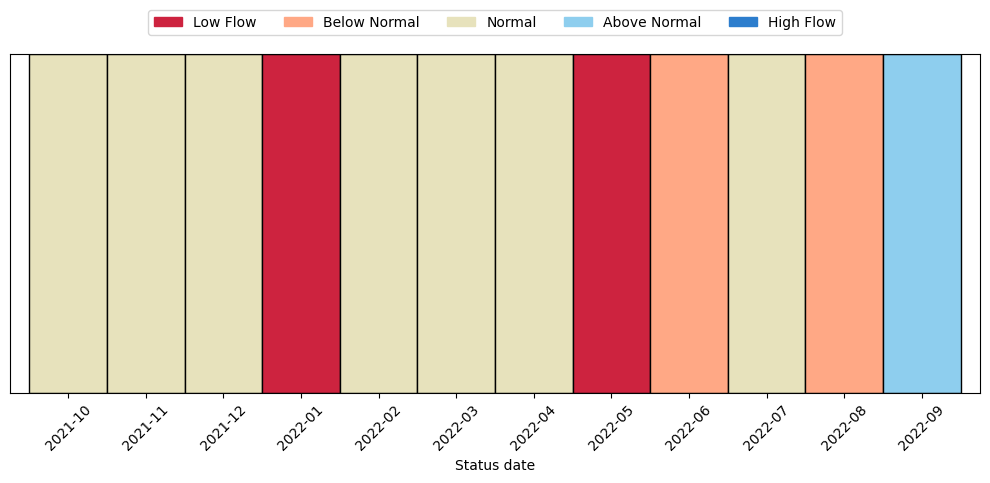

In [ ]:
#@title Plot
# Plot the calculated status over the recent year
recent_months = 12

# Restrict to the reference period so rankperc actually has values
df_ref_status = df_status[(df_status.index >= dt_start) & (df_status.index <= dt_end)]

# Map the 'flowcat' column to the predefined colors
bar_colors = df_status['cat_color'].iloc[-recent_months:]

# Bar plot with flow percentiles (commented out)
'''
ax = df_status['rankperc'].iloc[-recent_months:].plot(figsize=(10,5),
                                                 kind='bar',
                                                 ylabel='Percentile relative to the month',
                                                 xlabel='Status date',
                                                      edgecolor='k',
                                                 ylim=[0,1],
                                                 width=1,
                                                 color=bar_colors) # Set the color of the bars
'''
# Solid bar plot
ax = pd.Series([1]*recent_months).plot(figsize=(10,5),
                                       kind='bar',
                                       #ylabel='Percentile relative to the month',
                                       xlabel='Status date',
                                       edgecolor='k',
                                       ylim=[0,1],
                                       width=1,
                                       color=bar_colors) # Set the color of the bars

ax.set_yticks([])

# Create custom legend handles
legend_handles = []
for cat_num, cat_name in link_names.items():
    color = link_colors[cat_num]
    patch = mpatches.Patch(color=color, label=cat_name)
    legend_handles.append(patch)

# Add the legend above the plot
ax.legend(handles=legend_handles, bbox_to_anchor=(0.5, 1.15), loc='upper center', ncol=len(name_categories))

# Set date labels to YYYY-mm format to aid visualization
ax.set_xticklabels(df_status.index.strftime('%Y-%m').values[-recent_months:], rotation=45)

# Ensure the layout is tight to prevent labels overlapping
plt.tight_layout()

This cell will plot the last 12 months of the reference period so you can see how it plots with y as the rank percentile (you can do this outside the reference periof but only if you run the extra cell in step 5.5 above)

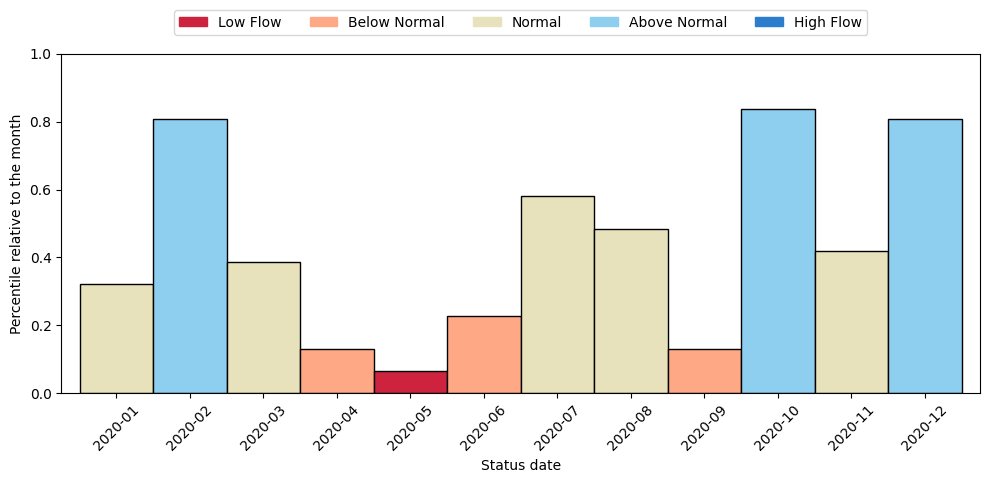

In [ ]:
recent_months = 12

# Select data up to the end of the reference period, then take the last 12 months
df_recent = df_status.loc[:dt_end].iloc[-recent_months:]

bar_colors = df_recent['cat_color']

ax = df_recent['rankperc'].plot(figsize=(10,5),
                                 kind='bar',
                                 ylabel='Percentile relative to the month',
                                 xlabel='Status date',
                                 edgecolor='k',
                                 ylim=[0,1],
                                 width=1,
                                 color=bar_colors)

legend_handles = []
for cat_num, cat_name in link_names.items():
    color = link_colors[cat_num]
    patch = mpatches.Patch(color=color, label=cat_name)
    legend_handles.append(patch)

ax.legend(handles=legend_handles, bbox_to_anchor=(0.5, 1.15), loc='upper center', ncol=len(name_categories))

ax.set_xticklabels(df_recent.index.strftime('%Y-%m').values, rotation=45)

plt.tight_layout()

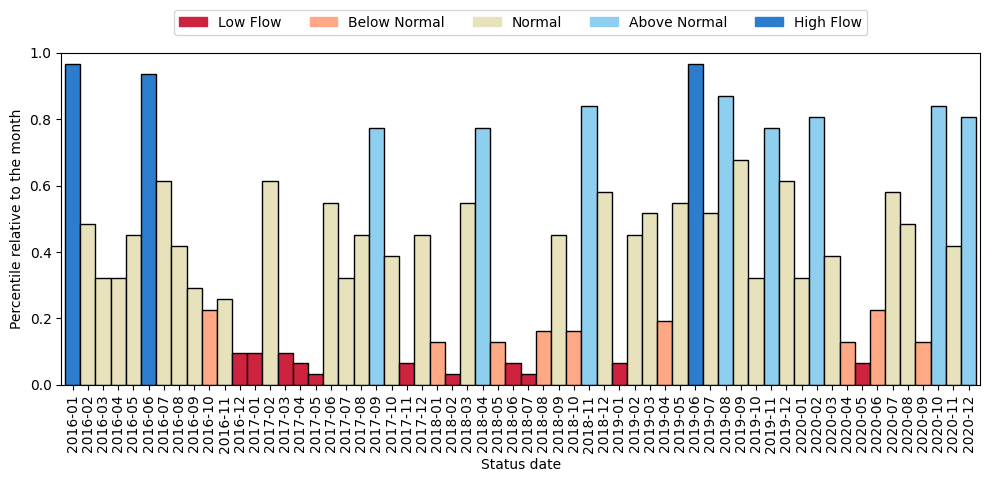

In [ ]:
recent_months = 60

# Select data up to the end of the reference period, then take the last 12 months
df_recent = df_status.loc[:dt_end].iloc[-recent_months:]

bar_colors = df_recent['cat_color']

ax = df_recent['rankperc'].plot(figsize=(10,5),
                                 kind='bar',
                                 ylabel='Percentile relative to the month',
                                 xlabel='Status date',
                                 edgecolor='k',
                                 ylim=[0,1],
                                 width=1,
                                 color=bar_colors)

legend_handles = []
for cat_num, cat_name in link_names.items():
    color = link_colors[cat_num]
    patch = mpatches.Patch(color=color, label=cat_name)
    legend_handles.append(patch)

ax.legend(handles=legend_handles, bbox_to_anchor=(0.5, 1.15), loc='upper center', ncol=len(name_categories))

ax.set_xticklabels(df_recent.index.strftime('%Y-%m').values, rotation=90)

plt.tight_layout()

# **7. Export the status table**

In [ ]:
# Exclude the colours column
df_status_export = df_status.drop(columns=['cat_color'])

df_status_export.to_csv(f'{folder_output}/status.csv')

---

# **8. Calculate status using the HydroSOS status on the GitHub repository**

This section shows how to calculate hydrological status using the HydroSOS methodology, via the `statuscalc.py` script available in the GitHub repository (https://github.com/wmo-im/HydroSOS). The script should be run with the following parameters:

`python statuscalc.py input_directory output_directory --startYear --endYear`

Where:

* `input_directory`: the directory containing the daily flow series in .csv format to be processed. The script will attempt to analyze all .csv files in this directory, so any .csv files that should not be processed must be removed. See the files in the `HydroSOS/example_data/status/input` folder for the **expected format** of these files;

* `output_directory`: the directory where the processed .csv files will be written. They will have the same name as the input directory files, but with the prefix "cat_" added at the beginning of the name;

* `startYear`: an optional argument indicating the year to use as the start of the range for calculating the reference average flow;

* `endYear`: an optional argument indicating the year to use as the end of the range for calculating the reference average flow.

For more information and additional scripts, it is recommended to consult the existing documentation in `HydroSOS/README.md`.

In [ ]:
# Create the folder for output files if it doesn't exist
os.makedirs('output_hydrosos', exist_ok=True)

# Now run the script using shell command
!python ./HydroSOS/status/statuscalc.py ./HydroSOS/example_data/status/input/ ./output_hydrosos/ --startYear 1991 --endYear 2020

No date format set, defaulting to %d/%m/%Y.
No output length set, defaulting to 5 years.
39001.csv
There are 31 years of data in this file.
There are 0 missing data points, which is 0.0% of the total data
/content/./HydroSOS/status/statuscalc.py:127: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  refBy.loc[refBy['month'] == i, 'weibell_rank'] = refBy.loc[refBy['month'] == i, 'percentile_flow'].rank(na_option='keep')/(refBy.loc[refBy['month'] == i, 'percentile_flow'].count()+1)
12001.csv
There are 31 years of data in this file.
There are 0 missing data points, which is 0.0% of the total data
/content/./HydroSOS/status/statuscalc.py:127: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_in